In [1]:
import glob
import torch
import os
import json
from pathlib import Path
from PIL import Image
import random
from datasets import Dataset
from transformers import DonutProcessor, VisionEncoderDecoderModel
from transformers import VisionEncoderDecoderConfig
from transformers import GenerationConfig

from typing import Any, List, Tuple
from datasets.info import DatasetInfo
from datasets.splits import NamedSplit
from datasets.table import Table


import lightning as L
from torch.utils.data import DataLoader

from pathlib import Path
import re
from nltk import edit_distance
import numpy as np
import math

from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import LambdaLR


import mlflow

2025-04-15 17:14:15.353632: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-15 17:14:15.367831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-15 17:14:15.385627: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-15 17:14:15.391154: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-15 17:14:15.403910: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# !pip install -U transformers

In [3]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.4.1.post300
CUDA available: True
GPU name: Tesla T4
GPU count: 1


In [4]:
config = VisionEncoderDecoderConfig.from_pretrained(
    "naver-clova-ix/donut-base"
)
processor = DonutProcessor.from_pretrained(
    "naver-clova-ix/donut-base"
)

# first check the cnfig arguments to know some special token information
# print(config)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [5]:
# print(processor)

In [6]:
processor.tokenizer

XLMRobertaTokenizerFast(name_or_path='naver-clova-ix/donut-base', vocab_size=57522, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>', 'additional_special_tokens': ['<s_iitcdip>', '<s_synthdog>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	57521: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=True, special=True

In [7]:
# # load data in s3 into sagemaker domain
# !aws s3 cp s3://birdclef/donut/ ./donut/ --recursive

In [8]:
annotations_dir="./donut/vertical_bar_annotations/"
annotations_files=glob.glob(annotations_dir+"*")
print(annotations_files[0])
print(len(annotations_files))

image_dir="./donut/vertical_bar/"
images_files=glob.glob(image_dir+"*")
print(images_files[0])
print(len(images_files))

./donut/vertical_bar_annotations/00cc0db43de7.json
19189
./donut/vertical_bar/01486411bcbe.jpg
19189


In [9]:
# images_dir = "./donut/vertical_bar"
# annotations_dir = "./donut/vertical_bar_annotations"
# output_jsonl = "./donut/vertical_bar.jsonl"

# with open(output_jsonl, "w", encoding="utf-8") as out_file:
#     for fname in os.listdir(annotations_dir):
#         if not fname.endswith(".json"):
#             continue
#         image_id = os.path.splitext(fname)[0]
#         image_path = os.path.join(images_dir, f"{image_id}.jpg")
#         annotation_path = os.path.join(annotations_dir, fname)

#         if not os.path.exists(image_path):
#             print(f"Skip: {image_path} not found")
#             continue

#         with open(annotation_path, "r", encoding="utf-8") as f:
#             label_dict = json.load(f)

#         label_text = json.dumps(label_dict, ensure_ascii=False)

#         out_file.write(json.dumps({
#             "image_path": image_path,
#             "label_text": label_text
#         }, ensure_ascii=False) + "\n")

# print("Done. Saved as:", output_jsonl)

In [10]:
# format data with Huggingface dataset
annotations_dir = Path("./donut/vertical_bar_annotations")
images_dir = Path("./donut/vertical_bar")
annotations_files = annotations_dir.glob("*.json")

ds = Dataset.from_dict({"annotation_path": list(map(str, list(annotations_files)))})

In [11]:
ds

Dataset({
    features: ['annotation_path'],
    num_rows: 19189
})

In [12]:
def parse_image(batch):
    """
    Processes a batch of data by loading images corresponding to annotation file paths.

    This function takes a batch containing annotation paths, extracts the file IDs from these paths,
    and uses these IDs to load the corresponding image files. Each image is opened and stored in a list.
    The function assumes that the image files are named with the same file ID as the annotation files
    and are located in a directory specified by `images_dir`.

    Parameters:
    batch (dict): A dictionary containing a key "annotation_path", which maps to a list of paths to annotation files.
                  Each path is expected to be in string format.

    Returns:
    dict: A dictionary with a key "images", which maps to a list of loaded images corresponding to the annotation paths.

    Note:
    - The variable `images_dir` should be defined outside this function and must point to the directory containing the image files.
    - The function does not close the images; users of the function should handle this as necessary.
    - This function assumes that the image files have a '.jpg' extension.
    """
    annotation_paths = batch["annotation_path"]

    images = []

    # Traverse all JSON file paths
    for path in annotation_paths:
        # Extract the file ID from the annotation path
        file_id = Path(path).stem

        # Load the corresponding image
        image = Image.open(str(images_dir / f"{file_id}.jpg"))
        images.append(image)

    return {"images": images}

In [13]:
parse_image(
    {"annotation_path": ["./donut/vertical_bar_annotations/00cc0db43de7.json"]}
)

{'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x640>]}

In [14]:
ds1 = ds.map(parse_image, batched=True, num_proc=8)

Parameter 'function'=<function parse_image at 0x7f39c0b22840> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


#0:   0%|          | 0/3 [00:00<?, ?ba/s]

#1:   0%|          | 0/3 [00:00<?, ?ba/s]

#2:   0%|          | 0/3 [00:00<?, ?ba/s]

#4:   0%|          | 0/3 [00:00<?, ?ba/s]

#5:   0%|          | 0/3 [00:00<?, ?ba/s]

#3:   0%|          | 0/3 [00:00<?, ?ba/s]

#6:   0%|          | 0/3 [00:00<?, ?ba/s]

#7:   0%|          | 0/3 [00:00<?, ?ba/s]

/opt/conda/lib/python3.11/site-packages/datasets/table.py:1292: FutureWarning: promote has been superseded by promote_options='default'.
  block_group = [InMemoryTable(cls._concat_blocks(list(block_group), axis=axis))]
/opt/conda/lib/python3.11/site-packages/datasets/table.py:1318: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [15]:
ds1

Dataset({
    features: ['annotation_path', 'images'],
    num_rows: 19189
})

In [16]:
sample = ds1[0]

In [17]:
sample

{'annotation_path': 'donut/vertical_bar_annotations/00cc0db43de7.json',
 'images': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x640>}

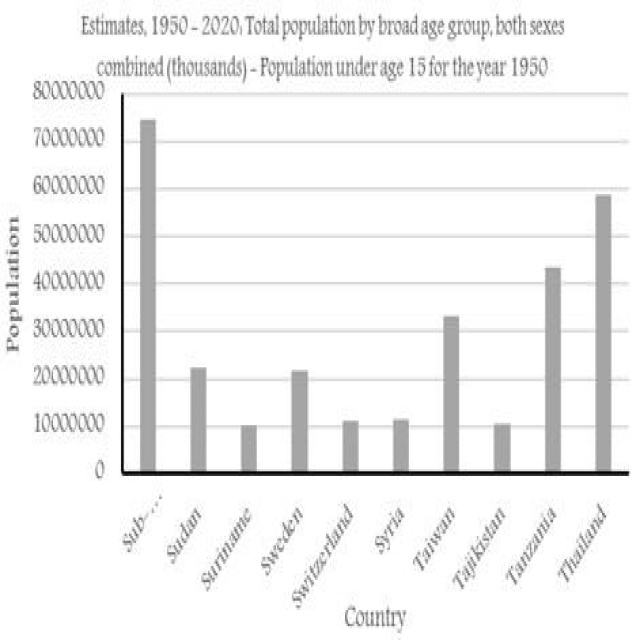

donut/vertical_bar_annotations/00cc0db43de7.json


In [18]:
display(sample["images"])
print(sample["annotation_path"])

In [19]:
# release memory
del ds

In [20]:
def parse_jsonl(batch):
    """
    convert json file into string with special tokens.
    each filed should be wrapped up by special tokens
    """
    annotation_paths = batch['annotation_path']
    gt_strings = []

    for path in annotation_paths:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # 1. grab field content
        title = data.get("title", "null")
        x_axis_title = data.get("x_axis_title", "null")
        y_axis_title = data.get("y_axis_title", "null")
        x_ticks = data.get("x_ticks", [])
        y_ticks = data.get("y_ticks", [])
        data_series = data.get("data_series", [])

        # 2. construct special tokens
        x_tick_str = "|".join(str(x) for x in x_ticks)
        y_tick_str = "|".join(str(y) for y in y_ticks)
        series_str = "|".join(f"{item['x']}:{round(float(item['y']), 2)}" for item in data_series)

        content = (
            f"<title>{title}</title>"
            f"<x_axis_title>{x_axis_title}</x_axis_title>"
            f"<y_axis_title>{y_axis_title}</y_axis_title>"
            f"<x_ticks>{x_tick_str}</x_ticks>"
            f"<y_ticks>{y_tick_str}</y_ticks>"
            f"<data_series>{series_str}</data_series>"
        )

        gt_strings.append(content)

    return {
        "gt_string": gt_strings
    }

In [21]:
# map parse_gt into Dataset
ds2=ds1.map(parse_jsonl, batched=True, num_proc=8)

/opt/conda/lib/python3.11/site-packages/datasets/table.py:1284: FutureWarning: promote has been superseded by promote_options='default'.
  return cls._concat_blocks(pa_tables_to_concat_vertically, axis=0)


#0:   0%|          | 0/3 [00:00<?, ?ba/s]

/opt/conda/lib/python3.11/site-packages/datasets/table.py:1284: FutureWarning: promote has been superseded by promote_options='default'.
  return cls._concat_blocks(pa_tables_to_concat_vertically, axis=0)


/opt/conda/lib/python3.11/site-packages/datasets/table.py:1284: FutureWarning: promote has been superseded by promote_options='default'.
  return cls._concat_blocks(pa_tables_to_concat_vertically, axis=0)


#1:   0%|          | 0/3 [00:00<?, ?ba/s]

...

#5:   0%|          | 0/3 [00:00<?, ?ba/s]

/opt/conda/lib/python3.11/site-packages/datasets/table.py:1284: FutureWarning: promote has been superseded by promote_options='default'.
  return cls._concat_blocks(pa_tables_to_concat_vertically, axis=0)


#6:   0%|          | 0/3 [00:00<?, ?ba/s]

#7:   0%|          | 0/3 [00:00<?, ?ba/s]

/opt/conda/lib/python3.11/site-packages/datasets/table.py:1292: FutureWarning: promote has been superseded by promote_options='default'.
  block_group = [InMemoryTable(cls._concat_blocks(list(block_group), axis=axis))]
/opt/conda/lib/python3.11/site-packages/datasets/table.py:1318: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [22]:
ds2

Dataset({
    features: ['annotation_path', 'images', 'gt_string'],
    num_rows: 19189
})

donut/vertical_bar_annotations/00cc0db43de7.json
<title>Estimates, 1950 - 2020: Total population by broad age group, both sexes combined (thousands) - Population under age 15 for the year 1950</title><x_axis_title>Country</x_axis_title><y_axis_title>Population</y_axis_title><x_ticks>Sub-...|Sudan|Suriname|Sweden|Switzerland|Syria|Taiwan|Tajikistan|Tanzania|Thailand</x_ticks><y_ticks>80000000|70000000|60000000|50000000|40000000|30000000|20000000|10000000|0</y_ticks><data_series>Sub-...:173076939.76|Sudan:52110713.12|Suriname:25229329.42|Sweden:50990655.46|Switzerland:27469444.73|Syria:27469444.73|Taiwan:76571664.05|Tajikistan:25229329.42|Tanzania:101033234.57|Thailand:136115037.17</data_series>


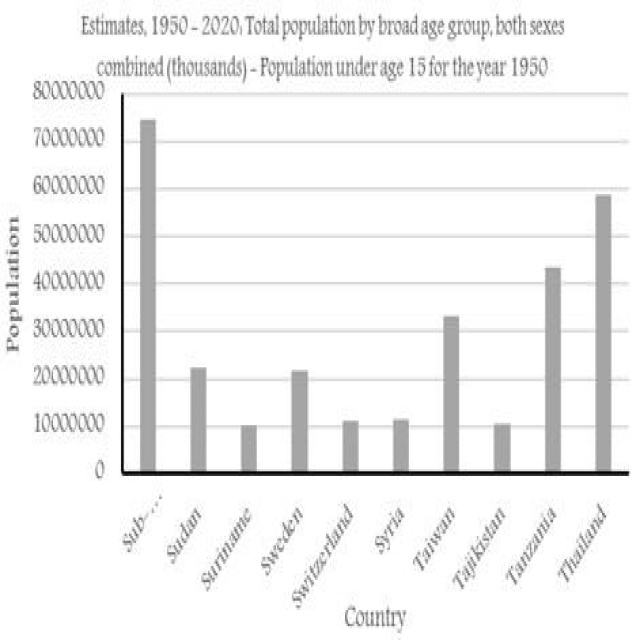

In [23]:
sample = ds2[0]
print(sample['annotation_path'])
print(sample['gt_string'])
display(sample['images'])

In [24]:
## some extra special tokens
title_start_token="<title>"
title_end_token="</title>"
x_axis_title_start_token="<x_axis_title>"
x_axis_title_end_token="</x_axis_title>"
y_axis_title_start_token="<y_axis_title>"
y_axis_title_end_token="</y_axis_title>"
x_ticks_start_token="<x_ticks>"
x_ticks_end_token="</x_ticks>"
y_ticks_start_token="<y_ticks>"
y_ticks_end_token="</y_ticks>"
data_series_start_token="<data_series>"
data_series_end_token="</data_series>"


special_tokens = [
    "<title>", "</title>",
    "<x_axis_title>", "</x_axis_title>",
    "<y_axis_title>", "</y_axis_title>",
    "<x_ticks>", "</x_ticks>",
    "<y_ticks>", "</y_ticks>",
    "<data_series>", "</data_series>"
]

In [25]:
processor.tokenizer.add_special_tokens({
    "additional_special_tokens": special_tokens
})

12

In [26]:
processor.tokenizer

XLMRobertaTokenizerFast(name_or_path='naver-clova-ix/donut-base', vocab_size=57522, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>', 'additional_special_tokens': ['<title>', '</title>', '<x_axis_title>', '</x_axis_title>', '<y_axis_title>', '</y_axis_title>', '<x_ticks>', '</x_ticks>', '<y_ticks>', '</y_ticks>', '<data_series>', '</data_series>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, s

In [27]:
# release memory
del ds1

In [28]:
lengths = [len(processor.tokenizer(gt)["input_ids"]) for gt in ds2["gt_string"]]

import numpy as np
print("📊 Max length:", np.max(lengths))
print("📊 95th percentile:", np.percentile(lengths, 95))
print("📊 Mean:", np.mean(lengths))

📊 Max length: 619
📊 95th percentile: 266.0
📊 Mean: 201.64891343999167


In [29]:
int(np.percentile(lengths, 95)) + 20

286

In [28]:
image_height=560
image_width=560
max_length=286

In [29]:
# setup the config file
config.encoder.image_size = (image_height, image_width)
config.decoder.max_length = max_length

In [30]:
# setup the processor
processor.image_processor.size = {
    "height": image_height,
    "width": image_width,
}

In [31]:
# processor.tokenizer(sample['gt_string']).input_ids

In [32]:
# processor.tokenizer.tokenize(sample['gt_string'],add_special_tokens=True)

In [33]:
# config

In [34]:
# print(processor.tokenizer.special_tokens_map)
# print(config.decoder_start_token_id, config.pad_token_id, config.eos_token_id)

In [36]:
# update config file
config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids("<s>")
config.pad_token_id = processor.tokenizer.convert_tokens_to_ids("<pad>")
config.eos_token_id = processor.tokenizer.convert_tokens_to_ids("</s>")

In [37]:
# print(processor.tokenizer.special_tokens_map)
# print(config.decoder_start_token_id, config.pad_token_id, config.eos_token_id)

In [38]:
print(processor.tokenizer.bos_token_id)
print(processor.tokenizer.pad_token_id)
print(processor.tokenizer.eos_token_id)

0
1
2


In [39]:
# split train and test dataset
ds3 = ds2.train_test_split(test_size=0.3, shuffle=True, seed=42)

In [40]:
ds3

DatasetDict({
    train: Dataset({
        features: ['annotation_path', 'images', 'gt_string'],
        num_rows: 13432
    })
    test: Dataset({
        features: ['annotation_path', 'images', 'gt_string'],
        num_rows: 5757
    })
})

In [41]:
# release memory
del ds2

In [42]:
# the donut model uses CrossEntropyLoss as loss function for training
# we need to give the ignore-index for pad_token, let CrossEntropyLoss function ignore the loss values of this part

loss_ignore_index=-100

In [43]:
from torch.utils.data import Dataset
class DonutDataset(Dataset):
    def __init__(self, 
                 dataset,
                 split,
                 max_length,
                 loss_ignore_index,
    ):
        super().__init__()

        self.max_length = max_length
        self.split = split
        self.dataset = dataset[self.split]
        self.loss_ignore_index=loss_ignore_index
        self.dataset_length = len(self.dataset)

        self.gt_token_sequences=[]

        for sample in self.dataset:
            self.gt_token_sequences.append([sample['gt_string']])
        

    def __len__(self):
        return self.dataset_length

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

        sample = self.dataset[idx]

        # inputs
        pixel_values = processor(
            sample["images"], random_padding=self.split == "train", return_tensors="pt"
        ).pixel_values
        pixel_values = pixel_values.squeeze()

        # targets
        # print(self.gt_token_sequences)
        # print(len(self.gt_token_sequences))
        target_sequence = random.choice(self.gt_token_sequences[idx])
        input_ids = processor.tokenizer(
            target_sequence,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )["input_ids"].squeeze(0)

        labels = input_ids.clone()
        labels[labels == processor.tokenizer.pad_token_id] = (
            self.loss_ignore_index
        )

        # print("input_ids:", input_ids.tolist())
        # print("labels   :", labels.tolist())

        return pixel_values, labels, target_sequence

In [44]:
# train_dataset = DonutDataset(
#     dataset=ds3,
#     max_length=max_length,
#     split="train",
#     loss_ignore_index=loss_ignore_index
# )
    

# val_dataset = DonutDataset(
#     dataset=ds3,
#     max_length=max_length,
#     split="test",
#     loss_ignore_index=loss_ignore_index
# )

In [45]:
# train_dataset

In [46]:
# val_dataset

In [59]:
pixel_values, labels, target_sequence=train_dataset[0]
print(pixel_values.shape)
print(pixel_values)
print(len(labels))
print(labels)
print(target_sequence)

input_ids: [57525, 56665, 46192, 20220, 38311, 46886, 20220, 38168, 2586, 30929, 55629, 20220, 50134, 2586, 17485, 7396, 44147, 9744, 19119, 34329, 11938, 57245, 48941, 48028, 48595, 57526, 57527, 50659, 57528, 57529, 40837, 2587, 56665, 46192, 39171, 38311, 46886, 57530, 57531, 54948, 39444, 45785, 13737, 47198, 24854, 45785, 46318, 5729, 37456, 15811, 40888, 45785, 34743, 27196, 45785, 34743, 27197, 24898, 46762, 26060, 34227, 45785, 34743, 16191, 37561, 45785, 43833, 51004, 20221, 45785, 48637, 52658, 42865, 45785, 56234, 24777, 4, 45785, 56234, 6772, 4, 57532, 57533, 40881, 45785, 23056, 45785, 657, 45785, 12219, 45785, 1866, 45785, 40556, 45785, 1829, 45785, 51412, 45785, 46051, 45785, 37930, 45785, 28268, 57534, 57535, 54948, 39444, 2586, 15628, 39539, 20121, 45785, 13737, 47198, 24854, 2586, 15628, 39539, 20121, 45785, 46318, 5729, 37456, 15811, 40888, 2586, 46702, 39539, 43137, 45785, 34743, 27196, 2586, 52266, 39539, 43037, 45785, 34743, 27197, 24898, 46762, 26060, 34227, 2846

In [47]:
class DonutDataModule(L.LightningDataModule):
    def __init__(
        self,
        dataset,
        processor,
        max_length=768,
        loss_ignore_index=-100,
        train_batch_size=32,
        val_batch_size=32,
        num_workers=0,
    ):
        super().__init__()
        self.dataset = dataset
        self.processor = processor
        self.max_length = max_length
        self.loss_ignore_index = loss_ignore_index
        self.train_batch_size = train_batch_size
        self.val_batch_size = val_batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.train_dataset = DonutDataset(
            dataset=self.dataset,
            split="train",
            max_length=self.max_length,
            loss_ignore_index=self.loss_ignore_index,
        )
        self.val_dataset = DonutDataset(
            dataset=self.dataset,
            split="test",
            max_length=self.max_length,
            loss_ignore_index=self.loss_ignore_index,
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.train_batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.val_batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

In [48]:
# dm = DonutDataModule(
#     dataset=ds3,
#     processor=processor,
#     max_length=max_length,
#     loss_ignore_index=loss_ignore_index,
#     train_batch_size=16,
#     val_batch_size=16
# )

# dm.setup()

# train_loader = dm.train_dataloader()
# val_loader = dm.val_dataloader()

In [49]:
# pixel_values, labels, target_sequence = next(iter(train_loader))

# print(pixel_values.shape)       # ([32, 3, 560, 560])
# print(labels.shape)             # e.g. torch.Size([32, 286])
# print(target_sequence[:2])    

In [64]:
# pixel_values, labels, target_sequence = next(iter(val_loader))

# print(pixel_values.shape)       # ([32, 3, 560, 560])
# print(labels.shape)             # e.g. torch.Size([32, 286])
# print(target_sequence[:2])  

torch.Size([32, 3, 560, 560])
torch.Size([32, 286])
('<title>Sex ratio by age (50 year olds) (UNWPP, 2017) in the Year 2000</title><x_axis_title>SEX RATIO</x_axis_title><y_axis_title>SEX RATIO</y_axis_title><x_ticks>Ecuador|Egypt|El Salvador|Equatorial Guinea|Erirea|Estonia|Eswatini|Ethiopia|Europe|Fiji</x_ticks><y_ticks>120|100|80|60|40|20|0</y_ticks><data_series>Ecuador:223.69|Egypt:238.43|El Salvador:189.8|Equatorial Guinea:239.9|Erirea:234.01|Estonia:198.64|Eswatini:195.69|Ethiopia:217.8|Europe:222.22|Fiji:234.01</data_series>', '<title>Sex ratio by age (40 year olds) (UNWPP, 2017) in the year 1965</title><x_axis_title>Sex ratio</x_axis_title><y_axis_title>Sex ratio</y_axis_title><x_ticks>Curacao|Cyprus|Czechia|Democratic Republic...|Denmark|Djibouti|Dominican Republic|Eastern Africa|Eastern Asia|Eastern Europe</x_ticks><y_ticks>120|100|80|60|40|20|0</y_ticks><data_series>Curacao:219.29|Cyprus:208.28|Czechia:219.29|Democratic Republic...:197.27|Denmark:222.05|Djibouti:222.05|Domini

In [56]:
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base", config=config)


Config of the encoder: <class 'transformers.models.donut.modeling_donut_swin.DonutSwinModel'> is overwritten by shared encoder config: DonutSwinConfig {
  "attention_probs_dropout_prob": 0.0,
  "depths": [
    2,
    2,
    14,
    2
  ],
  "drop_path_rate": 0.1,
  "embed_dim": 128,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": [
    560,
    560
  ],
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-05,
  "mlp_ratio": 4.0,
  "model_type": "donut-swin",
  "num_channels": 3,
  "num_heads": [
    4,
    8,
    16,
    32
  ],
  "num_layers": 4,
  "patch_size": 4,
  "path_norm": true,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.51.3",
  "use_absolute_embeddings": false,
  "window_size": 10
}

Config of the decoder: <class 'transformers.models.mbart.modeling_mbart.MBartForCausalLM'> is overwritten by shared decoder config: MBartConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cros

In [58]:
# extend decoder embedding layer
model.decoder.resize_token_embeddings(len(processor.tokenizer))

model.config.eos_token_id = processor.tokenizer.eos_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids("<s>")
model.config.max_length =max_length
model.config.pad_token_id=processor.tokenizer.pad_token_id

model.config.encoder.pad_token_id=processor.tokenizer.pad_token_id
model.config.decoder.bos_token_id=processor.tokenizer.bos_token_id
model.config.encoder.bos_token_id=processor.tokenizer.bos_token_id
model.config.update({"special_tokens": processor.tokenizer.additional_special_tokens})

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [59]:
print("decoder_start_token_id:", model.config.decoder_start_token_id)
print("token:", processor.tokenizer.convert_ids_to_tokens(model.config.decoder_start_token_id))
print("model.config.max_length:", model.config.max_length)
print("vocab size:", len(processor.tokenizer))
print(model.config.pad_token_id)
print(processor.tokenizer.convert_tokens_to_ids("<title>"))
print(model.decoder.get_input_embeddings().weight.shape)   

decoder_start_token_id: 0
token: <s>
model.config.max_length: 286
vocab size: 57537
1
57525
torch.Size([57537, 1024])


In [60]:
model

VisionEncoderDecoderModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )

In [67]:
model.config

VisionEncoderDecoderConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "VisionEncoderDecoderModel"
  ],
  "decoder": {
    "activation_dropout": 0.0,
    "activation_function": "gelu",
    "add_cross_attention": true,
    "add_final_layer_norm": true,
    "attention_dropout": 0.0,
    "classifier_dropout": 0.0,
    "d_model": 1024,
    "decoder_attention_heads": 16,
    "decoder_ffn_dim": 4096,
    "decoder_layerdrop": 0.0,
    "decoder_layers": 4,
    "dropout": 0.1,
    "encoder_attention_heads": 16,
    "encoder_ffn_dim": 4096,
    "encoder_layerdrop": 0.0,
    "encoder_layers": 12,
    "init_std": 0.02,
    "is_decoder": true,
    "is_encoder_decoder": false,
    "max_position_embeddings": 1536,
    "model_type": "mbart",
    "num_hidden_layers": 12,
    "scale_embedding": true,
    "torch_dtype": "float32",
    "use_cache": true,
    "vocab_size": 57537
  },
  "encoder": {
    "attention_probs_dropout_prob": 0.0,
    "depths": [
      2,
      2,
      14,
 

In [82]:
model.encoder

DonutSwinModel(
  (embeddings): DonutSwinEmbeddings(
    (patch_embeddings): DonutSwinPatchEmbeddings(
      (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): DonutSwinEncoder(
    (layers): ModuleList(
      (0): DonutSwinStage(
        (blocks): ModuleList(
          (0): DonutSwinLayer(
            (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attention): DonutSwinAttention(
              (self): DonutSwinSelfAttention(
                (query): Linear(in_features=128, out_features=128, bias=True)
                (key): Linear(in_features=128, out_features=128, bias=True)
                (value): Linear(in_features=128, out_features=128, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): DonutSwinSelfOutput(
                (dense): Linear(in

In [83]:
for name, module in model.encoder.named_modules():
    print(name)


embeddings
embeddings.patch_embeddings
embeddings.patch_embeddings.projection
embeddings.norm
embeddings.dropout
encoder
encoder.layers
encoder.layers.0
encoder.layers.0.blocks
encoder.layers.0.blocks.0
encoder.layers.0.blocks.0.layernorm_before
encoder.layers.0.blocks.0.attention
encoder.layers.0.blocks.0.attention.self
encoder.layers.0.blocks.0.attention.self.query
encoder.layers.0.blocks.0.attention.self.key
encoder.layers.0.blocks.0.attention.self.value
encoder.layers.0.blocks.0.attention.self.dropout
encoder.layers.0.blocks.0.attention.output
encoder.layers.0.blocks.0.attention.output.dense
encoder.layers.0.blocks.0.attention.output.dropout
encoder.layers.0.blocks.0.drop_path
encoder.layers.0.blocks.0.layernorm_after
encoder.layers.0.blocks.0.intermediate
encoder.layers.0.blocks.0.intermediate.dense
encoder.layers.0.blocks.0.intermediate.intermediate_act_fn
encoder.layers.0.blocks.0.output
encoder.layers.0.blocks.0.output.dense
encoder.layers.0.blocks.0.output.dropout
encoder.lay

In [84]:
model.decoder

MBartForCausalLM(
  (model): MBartDecoderWrapper(
    (decoder): MBartDecoder(
      (embed_tokens): MBartScaledWordEmbedding(57537, 1024, padding_idx=1)
      (embed_positions): MBartLearnedPositionalEmbedding(1538, 1024)
      (layers): ModuleList(
        (0-3): 4 x MBartDecoderLayer(
          (self_attn): MBartSdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): GELUActivation()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (encoder_attn): MBartSdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (

In [85]:
for name, module in model.decoder.named_modules():
    print(name)


model
model.decoder
model.decoder.embed_tokens
model.decoder.embed_positions
model.decoder.layers
model.decoder.layers.0
model.decoder.layers.0.self_attn
model.decoder.layers.0.self_attn.k_proj
model.decoder.layers.0.self_attn.v_proj
model.decoder.layers.0.self_attn.q_proj
model.decoder.layers.0.self_attn.out_proj
model.decoder.layers.0.activation_fn
model.decoder.layers.0.self_attn_layer_norm
model.decoder.layers.0.encoder_attn
model.decoder.layers.0.encoder_attn.k_proj
model.decoder.layers.0.encoder_attn.v_proj
model.decoder.layers.0.encoder_attn.q_proj
model.decoder.layers.0.encoder_attn.out_proj
model.decoder.layers.0.encoder_attn_layer_norm
model.decoder.layers.0.fc1
model.decoder.layers.0.fc2
model.decoder.layers.0.final_layer_norm
model.decoder.layers.1
model.decoder.layers.1.self_attn
model.decoder.layers.1.self_attn.k_proj
model.decoder.layers.1.self_attn.v_proj
model.decoder.layers.1.self_attn.q_proj
model.decoder.layers.1.self_attn.out_proj
model.decoder.layers.1.activation

In [87]:
def freeze_encoder(model):
    for param in model.encoder.parameters():
        param.requires_grad = False
    print("✅ Frozen encoder.")

In [88]:
def print_trainable_layers(model):
    print("Trainable layers:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"🟢 {name}")
        else:
            print(f"🔒 {name}")

In [89]:
freeze_encoder(model)

✅ Frozen encoder.


In [90]:
print_trainable_layers(model)

Trainable layers:
🔒 encoder.embeddings.patch_embeddings.projection.weight
🔒 encoder.embeddings.patch_embeddings.projection.bias
🔒 encoder.embeddings.norm.weight
🔒 encoder.embeddings.norm.bias
🔒 encoder.encoder.layers.0.blocks.0.layernorm_before.weight
🔒 encoder.encoder.layers.0.blocks.0.layernorm_before.bias
🔒 encoder.encoder.layers.0.blocks.0.attention.self.relative_position_bias_table
🔒 encoder.encoder.layers.0.blocks.0.attention.self.query.weight
🔒 encoder.encoder.layers.0.blocks.0.attention.self.query.bias
🔒 encoder.encoder.layers.0.blocks.0.attention.self.key.weight
🔒 encoder.encoder.layers.0.blocks.0.attention.self.key.bias
🔒 encoder.encoder.layers.0.blocks.0.attention.self.value.weight
🔒 encoder.encoder.layers.0.blocks.0.attention.self.value.bias
🔒 encoder.encoder.layers.0.blocks.0.attention.output.dense.weight
🔒 encoder.encoder.layers.0.blocks.0.attention.output.dense.bias
🔒 encoder.encoder.layers.0.blocks.0.layernorm_after.weight
🔒 encoder.encoder.layers.0.blocks.0.layernorm_a

In [56]:
print("🧩 pad_token_id:", processor.tokenizer.pad_token_id)

🧩 pad_token_id: 1


In [43]:
# set up the expirment name
# mlflow.set_experiment("donut-model-mlflow-1")
# mlflow.set_tracking_uri(f"./mlruns")

In [64]:
from torch.optim.lr_scheduler import LambdaLR
import math

def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps, num_cycles=0.5, last_epoch=-1):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * num_cycles * 2.0 * progress)))
    return LambdaLR(optimizer, lr_lambda, last_epoch=last_epoch)

In [65]:
class DonutModelPLModule(L.LightningModule):
    def __init__(self, config, processor, model):
        super().__init__()
        self.config = config
        self.processor = processor
        self.model = model

        if self.config.get("freeze_encoder", True):
            self.freeze_encoder()

        self.print_trainable_parameters()

        self.generation_cfg = GenerationConfig(
            max_length=self.config.get("max_length", 768),
            early_stopping=True,
            do_sample=False,
            num_beams=4,
            use_cache=True,
            bad_words_ids=[[self.processor.tokenizer.unk_token_id]],
            pad_token_id=self.processor.tokenizer.pad_token_id,
            eos_token_id=self.processor.tokenizer.eos_token_id,
            return_dict_in_generate=True,
        )

    def freeze_encoder(self):
        for param in self.model.encoder.parameters():
            param.requires_grad = False

    def print_trainable_parameters(self):
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in self.parameters())
        print(f"Trainable parameters: {trainable_params} / {total_params}")

    def training_step(self, batch, batch_idx):
        pixel_values, labels, _ = batch
        pixel_values = pixel_values.to(self.device)
        labels = labels.to(self.device)

        outputs = self.model(pixel_values, labels=labels)
        loss = outputs.loss

        # mlflow.log_metric("Training Batch Loss", loss.item(), step=batch_idx)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx, dataset_idx=0):
        pixel_values, labels, answers = batch
        pixel_values = pixel_values.to(self.device)
        labels = labels.to(self.device)
    
        # CrossEntropyLoss (token-level)
        with torch.no_grad():
            outputs = self.model(pixel_values, labels=labels)
            val_loss = outputs.loss
    
            # Log to MLflow & Lightning both
            # mlflow.log_metric("val_loss", val_loss.item(), step=batch_idx)
            self.log("val_loss", val_loss)
    
        # Optional: Edit Distance evaluation
        if self.config.get("log_edit_distance", False):
            decoder_input_ids = torch.full(
                (pixel_values.size(0), 1),
                self.model.config.decoder_start_token_id,
                device=self.device,
            )
    
            generated = self.model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                generation_config=self.generation_cfg,
            )
    
            predictions = self.processor.tokenizer.batch_decode(
                generated.sequences, skip_special_tokens=True
            )
    
            scores = []
            for pred, ans in zip(predictions, answers):
                denom = max(len(pred), len(ans))
                score = edit_distance(pred, ans) / denom if denom > 0 else 1.0
                scores.append(score)
    
            # 📝 Log Edit Distance
            avg_score = np.mean(scores)
            # mlflow.log_metric("val_edit_distance", avg_score, step=batch_idx)
            self.log("val_edit_distance", avg_score)
    
        return {"val_loss": val_loss}


    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        pixel_values = batch.to(self.device)
        batch_size = pixel_values.shape[0]

        decoder_input_ids = torch.full(
            (batch_size, 1),
            self.model.config.decoder_start_token_id,
            dtype=torch.long,
            device=self.device,
        )

        outputs = self.model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            generation_config=self.generation_cfg,
        )

        predictions = self.processor.tokenizer.batch_decode(
            outputs.sequences, skip_special_tokens=True
        )

        return predictions

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.config.get("lr", 5e-5))
    
        total_steps = self.config.get("max_epochs", 30) * self.config.get("steps_per_epoch", 1000)
        warmup_steps = self.config.get("warmup_steps", int(0.1 * total_steps))
    
        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            warmup_steps=warmup_steps,
            total_steps=total_steps,
            num_cycles=0.5
        )
    
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",  # update every step
                "frequency": 1,
            }
        }

In [66]:
train_config = {"max_epochs":30,
          "val_check_interval":1, # how many times we want to validate during an epoch
          "check_val_every_n_epoch":1,
          "gradient_clip_val":0.1,
          "lr":1e-6,
          "train_batch_sizes": [32],
          "val_batch_sizes": [32],
          "num_nodes": 4,
          # "warmup_steps": 300,
          "result_path": "./donut/result",
          "log_edit_distance": False,
          "verbose": True,
          }

In [67]:
model_module = DonutModelPLModule(train_config, processor, model)

Trainable parameters: 127683584 / 201864312


In [68]:
model.generation_config

GenerationConfig {
  "bos_token_id": 0,
  "decoder_start_token_id": 0,
  "eos_token_id": 2,
  "forced_eos_token_id": 2,
  "max_length": 286,
  "pad_token_id": 1
}

In [69]:
dm = DonutDataModule(
    dataset=ds3,
    processor=processor,
    max_length=max_length,
    loss_ignore_index=loss_ignore_index,
    train_batch_size=32,
    val_batch_size=32,
    num_workers=2
)

In [ ]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import Callback, ModelCheckpoint, EarlyStopping

# create EarlyStopping callback
early_stop_callback = EarlyStopping(monitor="val_loss", patience=6, verbose=False, mode="min")

# create ModelCheckpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath="./donut/result",  
    filename="{epoch}-{val_loss:.2f}",  
    save_top_k=1,  
    verbose=True,
    monitor="val_loss",  
    mode="min", 
)

# initilize Trainer
trainer = Trainer(
        accelerator="gpu",
        devices=1,
        max_epochs=train_config.get("max_epochs"),
        # val_check_interval=train_config.get("val_check_interval"),
        check_val_every_n_epoch=train_config.get("check_val_every_n_epoch"),
        gradient_clip_val=train_config.get("gradient_clip_val"),
        precision=16,  # mixed precision
        num_sanity_val_steps=0,
        callbacks=[early_stop_callback, checkpoint_callback],  # add callbacks
)

trainer.fit(model_module,datamodule=dm)
# # use mlflow
# with mlflow.start_run():
#     # record parameters
#     mlflow.log_params(config)

#     # train the model
#     trainer.fit(model_module,datamodule=dm)

#     # log model
#     mlflow.pytorch.log_model(model_module.model, "model")
#     mlflow.end_run()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                      | Params | Mode
-----------------------------------------------------------
0 | model | VisionEncoderDecoderModel | 201 M  | eval
-----------------------------------------------------------
127 M     Trainable params
74.2 M    Non-trainable params
201 M     Total params
807.457   Total estimated model params size (MB)
0         Modules in train mode
484       Modules in eval mode
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.


Training: |          | 0/? [00:00<?, ?it/s]

Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.


Validation: |          | 0/? [00:00<?, ?it/s]

Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 29. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
Epoch 0, global step 420: 'val_loss' reached 8.34057 (best 8.34057), saving model to '/home/sagemaker-user/donut/result/epoch=0-val_loss=8.34.ckpt' as top 1
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.


...

Epoch 11, global step 5040: 'val_loss' reached 2.64673 (best 2.64673), saving model to '/home/sagemaker-user/donut/result/epoch=11-val_loss=2.65.ckpt' as top 1
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 12, global step 5460: 'val_loss' reached 2.42925 (best 2.42925), saving model to '/home/sagemaker-user/donut/result/epoch=12-val_loss=2.43.ckpt' as top 1
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 13, global step 5880: 'val_loss' reached 2.27905 (best 2.27905), saving model to '/home/sagemaker-user/donut/result/epoch=13-val_loss=2.28.ckpt' as top 1
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.
